# LangGraph + Pydantic v2 state

`MyState` is a **Pydantic `BaseModel`** (not a `TypedDict`). Defaults like `steps=[]` apply when you construct `MyState(messages=[...])`.

LangGraph still returns a **dict** from `invoke()`; use `MyState.model_validate(reply)` for attribute access.

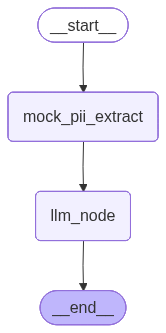

In [38]:
from contextlib import contextmanager
from contextvars import ContextVar
from dataclasses import dataclass
from operator import add
import os
from typing import Annotated, Dict, cast

import httpx
from IPython.display import Image, display
from langchain_core.messages import (
    AIMessage,
    AnyMessage,
    BaseMessageChunk,
    HumanMessage,
    convert_to_messages,
    convert_to_openai_messages,
    message_chunk_to_message,
)
from langchain_core.prompts import ChatPromptTemplate
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
import openai
from pydantic import BaseModel, ConfigDict, Field

current_thread_id: ContextVar[str] = ContextVar("current_thread_id", default="default")
current_merge: ContextVar[MySafeMerge | None] = ContextVar(
    "current_merge", default=None
)

API_KEY = os.getenv("MODEL_API_KEY_DEV")
if not API_KEY:
    raise RuntimeError("Missing MODEL_API_KEY_DEV ...")

BASE_URL = os.getenv("MODEL_BASE_URL_CLEAN")
if not BASE_URL:
    raise RuntimeError("Missing MODEL_BASE_URL_CLEAN ...")

CA_CERT_PATH = "/certs/.caroot/rootCA.pem"
verify_config = CA_CERT_PATH if os.path.exists(CA_CERT_PATH) else True
http_client = httpx.Client(verify=verify_config, timeout=120.0)

MODEL = "ollama_chat/deepseek-r1:7b"


@dataclass
class MonitorSession:
    thread_id: str
    merge: MySafeMerge

    @property
    def config(self) -> dict:
        return {"configurable": {"thread_id": self.thread_id}}

    def state(self, *, messages) -> MyState:
        if current_merge.get() is not self.merge:
            raise RuntimeError("MyState only permitted inside this session")
        return MyState(messages=messages)

    def invoke(self, graph, input):
        token = current_thread_id.set(self.thread_id)
        try:
            return graph.invoke(input, config=self.config)
        finally:
            current_thread_id.reset(token)


@contextmanager
def message_monitor_session(thread_id: str):
    merge = MySafeMerge()
    token_merge = current_merge.set(merge)
    token_thread_id = current_thread_id.set(thread_id)

    session = MonitorSession(thread_id=thread_id, merge=merge)
    try:
        yield session
    finally:
        print(f"END SESSION with option to persist and vaults part of {merge}")
        current_thread_id.reset(token_thread_id)
        current_merge.reset(token_merge)


class MyVault:
    def __init__(self):
        self.key_value: dict[str, str] = {}

    def get(self, key: str) -> str:
        return self.key_value.get(key)

    def set(self, key: str, value: str):
        if self.get(key):
            raise ValueError(f"Key {key} already exists")
        self.key_value[key] = value

    def clear(self):
        self.key_value = {}


vault = MyVault()


class MySafeMerge:
    # This is a safeguard within the graph that inspects all messages.
    # It protects against malicious nodes that add messages with PII.
    # Issue is that it resides outside the graph so we might not catch
    # its LLM calls (for filtering PII) as part of the graph execution.

    def __init__(self):
        self._vaults: Dict[str, MyVault] = {}
        self._left_scrubbed: Dict[str, bool] = {}

    def _get_vault_for_thread(self, thread_id: str) -> MyVault:
        if thread_id not in self._vaults:
            self._vaults[thread_id] = MyVault()
        return self._vaults[thread_id]

    def _get_left_scrubbed_for_thread(self, thread_id: str) -> bool:
        if thread_id not in self._left_scrubbed:
            self._left_scrubbed[thread_id] = False
        return self._left_scrubbed[thread_id]

    def _set_left_scrubbed_for_thread(self, thread_id: str, value: bool) -> None:
        self._left_scrubbed[thread_id] = value

    def _clear_vault_for_thread(self, thread_id: str) -> None:
        if thread_id not in self._vaults:
            raise ValueError(f"Thread {thread_id} not found.")
        self._vaults[thread_id].clear()

    def __call__(self, left, right):

        thread_id = current_thread_id.get()
        # Right is the list of new messages to be added. This is commonly
        # passed while the graph executes. Nodes add messages. Every message
        # is sanitized before being added to the list.
        if not isinstance(right, list):
            right = [right]
        right = [
            message_chunk_to_message(cast(BaseMessageChunk, m))
            for m in convert_to_messages(right)
        ]
        right = [self.scrub_message(m, thread_id) for m in right]

        # Left is the list of already messages. In most cases
        # we have already scrubbed this list. However, if the graph
        # is invoked with a new state, the list may not be scrubbed.
        # So we scrub the left list once initially
        if not self._get_left_scrubbed_for_thread(thread_id):
            if not isinstance(left, list):
                left = [left]
            left = [
                message_chunk_to_message(cast(BaseMessageChunk, m))
                for m in convert_to_messages(left)
            ]
            left = [self.scrub_message(m, thread_id) for m in left]
            self._set_left_scrubbed_for_thread(thread_id, True)

        # Let langgraph do the rest - this might include removing messages that
        # we have scrubbed, which means wasted effort (RemoveMessage)
        return add_messages(left, right)

    def reset_for_thread(self, thread_id: str):
        print(f"RESET for thread_id = {thread_id}")
        self._set_left_scrubbed_for_thread(thread_id, False)
        self._clear_vault_for_thread(thread_id)

    def scrub_message(self, message: AnyMessage, thread_id: str):
        # TODO: handle other messages types and consider to rebuild messages instead of mutating them
        if not isinstance(message.content, str):
            return message

        print(f"SCRUB on thread_id = {thread_id}")
        message.content = self.scrub_content(message.content)
        return message

    def scrub_content(self, content: str):
        print(f"SCRUB {content}")
        return content.replace("PII", "REDACTED")


def _message_reducer(left, right):
    merge = current_merge.get()
    if merge is None:
        raise RuntimeError("No merge context found: outside message_monitor_session?")
    return merge(left, right)


class MyState(BaseModel):
    model_config = ConfigDict(arbitrary_types_allowed=True)

    messages: Annotated[list[AnyMessage], _message_reducer] = Field(
        default_factory=list
    )
    cleared_messages: Annotated[list[AnyMessage], add_messages] = Field(
        default_factory=list
    )
    steps: Annotated[list[str], add] = Field(default_factory=list)


class LlmNodeOpenAI:
    def __init__(self, client: openai.OpenAI, model: str, template: ChatPromptTemplate):
        self._client = client
        self._model = model
        self._template = template

    def __call__(self, state: MyState) -> dict:
        prompt_value = self._template.invoke(state.messages)
        openai_messages = convert_to_openai_messages(prompt_value.messages)
        completion = self._client.chat.completions.create(
            model=self._model,
            messages=openai_messages,
            temperature=0.0,
        )
        answer = completion.choices[0].message.content or ""
        return {
            "messages": [AIMessage(content=answer)],
            "steps": ["LlmNodeOpenAI"],
        }


def create_llm_client(api_key, base_url, http_client, max_retries=0):
    return openai.OpenAI(
        api_key=api_key,
        base_url=base_url,
        http_client=http_client,
        max_retries=max_retries,
    )


def mock_llm(state: MyState) -> dict:
    print(state)
    return {
        "messages": [{"role": "ai", "content": "hello world"}],
        "steps": ["mock_llm"],
    }


def mock_pii_extract(state: MyState) -> dict:
    for m in state.messages[::-1]:
        if m.type == "human":
            print("HUMAN")
        if m.type == "ai":
            print("AI")
        print(m.content)


client = create_llm_client(API_KEY, BASE_URL, http_client)

template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are very friendly, reply in a short and concise manner. "
            "Make sure your reply reflects your mood.",
        ),
        ("user", "{input}"),
    ]
)


build_graph = StateGraph(MyState)

build_graph.add_node("llm_node", LlmNodeOpenAI(client, MODEL, template))
build_graph.add_node("mock_pii_extract", mock_pii_extract)

build_graph.add_edge(START, "mock_pii_extract")
build_graph.add_edge("mock_pii_extract", "llm_node")
build_graph.add_edge("llm_node", END)

graph = build_graph.compile()


display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
def print_reply(out: MyState):
    for m in out.messages:
        m.pretty_print()

    for step in out.steps:
        print(step)


with message_monitor_session("Chat-A") as session:
    print(session.merge)
    user_text = "Hello, how are you PII?"
    state = MyState(messages=[HumanMessage(content=user_text)])
    reply = session.invoke(graph, state)
    print_reply(MyState.model_validate(reply))
    print("---- second invoke ----")

    user_text = "What is a cat? Reply in 10 words or less."
    state2 = session.state(messages=[HumanMessage(content=user_text)])
    reply = session.invoke(graph, state2)
    print_reply(MyState.model_validate(reply))

SCRUB on thread_id = Chat-A
SCRUB What is a cat? Reply in 10 words or less.
HUMAN
What is a cat? Reply in 10 words or less.
